# Imports


In [1]:
# File System
from pathlib import Path

# ML
import pandas as pd
import numpy as np

# Plot
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Loading and Exporting

## Parameters

In [2]:
dataset_folder = "Labeled_Datasets/Ecuador"   # folder path
file_name = "Ecuador_part_all.gzip.parquet"  # file name
dataset_procced_date = "2026_01_10"        # ("%Y_%m_%d")

# Recommended: working directory is: "Backbone-Graph/src"

## Load Data

In [3]:
# Note: Google Colab not supported anymore.

# Cluster\Local
# Recommended: working directory is: "Backbone-Graph/src"
file_name_no_suffixes = file_name.split(".")[0]
processed_dataset_path = Path("../../results") / dataset_folder / file_name_no_suffixes / dataset_procced_date
# Example: ""../results/Labeled_Datasets/Ecuador/Ecuador_part_4/2025_11_27"
print(f"Running on local/cluster.\nLoading data from: {processed_dataset_path}")

# Load the parquet file
df = pd.read_parquet(processed_dataset_path / f"processed_{file_name}")

# for testing
# df = df.sample(n = 50).reset_index(drop=True)

Running on local/cluster.
Loading data from: ../../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10


In [4]:
boots_scores =  pd.read_csv("boost_scores_5m.csv").drop_duplicates(subset=['accountid'])

print(boots_scores.columns.tolist())

['accountid', 'boost_score', 'is_control']


## Output

In [ ]:
folder_output_path = processed_dataset_path # save in the save folder as the processed dataset

# Authors Sets

### IO Set

In [5]:
io_authors_set = set(boots_scores[boots_scores["is_control"] == 0]["accountid"].astype(str).unique())
print(f"Total unique IO authors/accounts in the dataset: {len(io_authors_set)}")

Total unique IO authors/accounts in the dataset: 555


### Boost Set

In [6]:
boosts_top_percent_threshold = 0.5

boosts_top_absolute_number_threshold = int(len(boots_scores) * boosts_top_percent_threshold)

boost_authors_set = set(
    boots_scores
        .nlargest(boosts_top_absolute_number_threshold, 'boost_score')
        ['accountid']
        .astype(str)
)


print(f"Total unique boost authors in the dataset: {len(boost_authors_set)}")

Total unique boost authors in the dataset: 3801


### All Set

In [7]:
all_authors_set = set(df["accountid"].astype(str).unique())
print(f"Total unique authors in the dataset: {len(all_authors_set)}")

Total unique authors in the dataset: 21923


### Key Set

In [8]:
node_indicators = pd.read_parquet("../../results/Labeled_Datasets/Ecuador/Ecuador_part_all/2026_01_10/node_indicators.parquet")
key_autorhs_set = set(node_indicators.index.astype(str).unique())
print(f"Total unique key authors in the dataset: {len(key_autorhs_set)}")

Total unique key authors in the dataset: 1639


# Venn

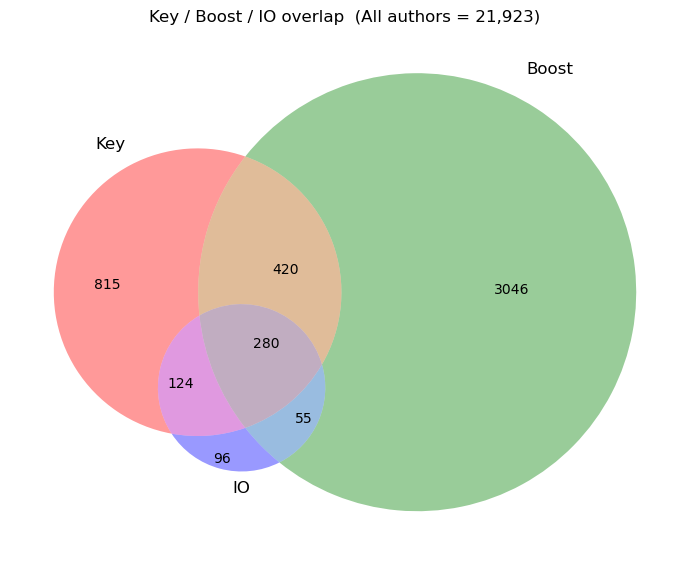

In [10]:
# --- Venn3 for the 3 meaningful subsets (Key, Boost, IO) ---
fig, ax = plt.subplots(figsize=(7, 7))
v = venn3(
    subsets=[key_autorhs_set, boost_authors_set, io_set],
    set_labels=("Key", "Boost", "IO"),
    ax=ax
)
ax.set_title(
    f"Key / Boost / IO overlap  (All authors = {len(all_authors_set):,})",
    fontsize=12
)
plt.tight_layout()
plt.show()

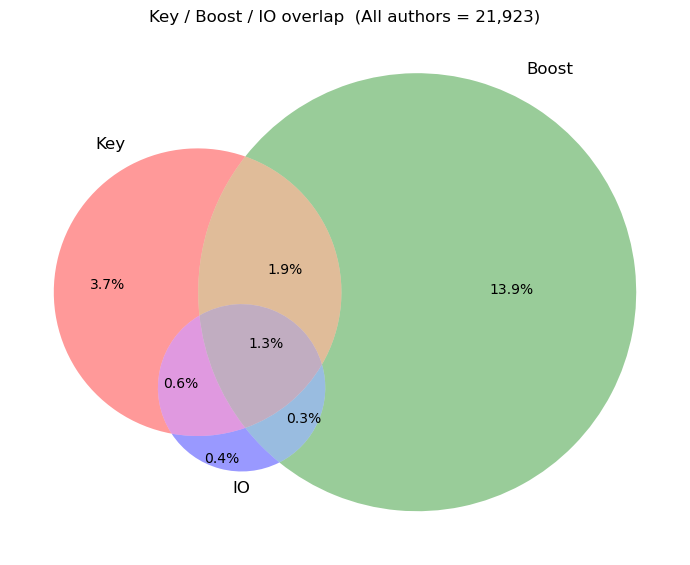

In [14]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

universe_size = len(all_authors_set)

fig, ax = plt.subplots(figsize=(7, 7))

v = venn3(
    subsets=[set(key_autorhs_set), set(boost_authors_set), set(io_set)],
    set_labels=("Key", "Boost", "IO"),
    ax=ax
)

# Replace counts with percentages
for subset_id in ('100', '010', '001', '110', '101', '011', '111'):
    label = v.get_label_by_id(subset_id)
    if label is not None:
        count = int(label.get_text())
        percent = 100 * count / universe_size
        label.set_text(f"{percent:.1f}%")

ax.set_title(
    f"Key / Boost / IO overlap  (All authors = {universe_size:,})",
    fontsize=12
)

plt.tight_layout()
plt.show()


<Figure size 800x800 with 0 Axes>

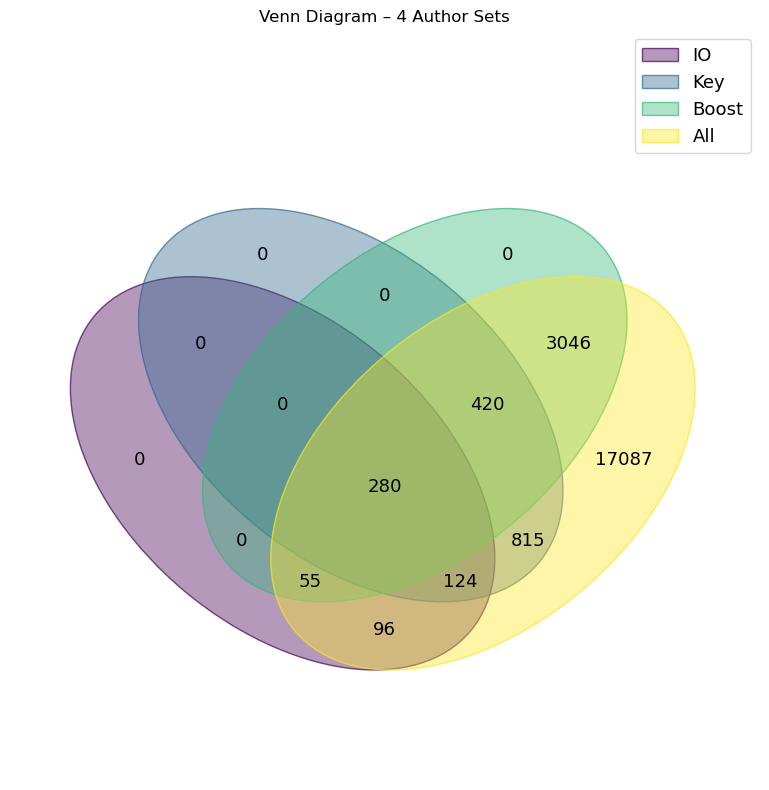

In [15]:
from venn import venn
import matplotlib.pyplot as plt

io_set    = set(io_authors_set)
key_set   = set(key_autorhs_set)
boost_set = set(boost_authors_set)
all_set   = set(all_authors_set)


sets_dict = {
    "IO": io_set,
    "Key": key_set,
    "Boost": boost_set,
    "All": all_set
}

plt.figure(figsize=(8, 8))
venn(sets_dict)

plt.title("Venn Diagram – 4 Author Sets")
plt.tight_layout()
plt.show()
